#IT362 Phase 1: Data
**Mental Health Apps Reviews - Arabic Only**

In [ ]:
!pip install -q google-play-scraper pandas openpyxl
print('Libraries installed')

Libraries installed


In [ ]:
import pandas as pd
from google_play_scraper import Sort, reviews_all
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
print('Ready')

Ready


In [ ]:
# Apps configuration - 4 apps
APPS = {
    "Labayh": "com.labayh",
    "Estinara": "com.estenarh.app",
    "Calm": "com.calm.android",
    "BetterHelp": "com.betterhelp"
}

TARGET_PER_APP = 1500

print(f'Apps: {list(APPS.keys())}')
print(f'Target: {TARGET_PER_APP} reviews per app')
print(f'Total: {TARGET_PER_APP * len(APPS)} reviews')

Apps: ['Labayh', 'Estinara', 'Calm', 'BetterHelp']
Target: 1500 reviews per app
Total: 6000 reviews


In [ ]:
# Collection function
def collect_reviews(package_id, app_name, limit=1500):
    print(f'Collecting {app_name}...', end=' ')
    start = time.time()

    try:
        result = reviews_all(
            package_id,
            sleep_milliseconds=0,
            lang='ar',
            country='sa',
            sort=Sort.NEWEST
        )
        result = result[:limit]
        print(f'{len(result)} in {time.time()-start:.1f}s')
        return result
    except Exception as e:
        print(f'Error: {e}')
        return []

# Collect from all apps
print('\nStarting collection...')
print('='*60)

total_start = time.time()
raw_data = {}

for name, pkg in APPS.items():
    raw_data[name] = collect_reviews(pkg, name, TARGET_PER_APP)

total_time = time.time() - total_start
print('='*60)
print(f'Completed in {total_time/60:.1f} minutes')


Starting collection...
Completed in 0.0 minutes


In [ ]:
# Convert to DataFrames
print('\nProcessing...')

dfs = {}
for name, reviews_list in raw_data.items():
    if reviews_list:
        dfs[name] = pd.DataFrame([{
            'app_name': name,
            'review_id': r['reviewId'],
            'user_name': r['userName'],
            'rating': r['score'],
            'review_text': r['content'],
            'review_date': r['at'],
            'thumbs_up': r['thumbsUpCount'],
            'reply_content': r.get('replyContent'),
            'reply_date': r.get('repliedAt'),
            'app_version': r.get('reviewCreatedVersion', 'N/A')
        } for r in reviews_list])
        print(f'{name}: {len(dfs[name])} reviews')

print('Processing complete')


Processing...
Labayh: 754 reviews
Estinara: 85 reviews
Calm: 1002 reviews
BetterHelp: 23 reviews
Processing complete


In [ ]:
# Filter ARABIC ONLY
print('\nFiltering Arabic reviews...')

def is_arabic(text):
    if pd.isna(text) or len(str(text)) < 10:
        return False
    arabic = sum(1 for c in str(text) if '\u0600' <= c <= '\u06FF')
    return arabic > len(text) * 0.3

arabic_dfs = {}
for name, df in dfs.items():
    df_arabic = df[df['review_text'].apply(is_arabic)].copy()
    arabic_dfs[name] = df_arabic

    pct = (len(df_arabic) / len(df) * 100) if len(df) > 0 else 0
    print(f'{name}: {len(df_arabic)}/{len(df)} Arabic ({pct:.1f}%)')

print('\nArabic filtering complete')


Filtering Arabic reviews...
Labayh: 538/754 Arabic (71.4%)
Estinara: 64/85 Arabic (75.3%)
Calm: 422/1002 Arabic (42.1%)
BetterHelp: 10/23 Arabic (43.5%)

Arabic filtering complete


In [ ]:
# Combine all Arabic reviews
combined = pd.concat(arabic_dfs.values(), ignore_index=True)

print(f'\nTotal Arabic reviews: {len(combined)}')
print('\nPer app:')
for name, count in combined['app_name'].value_counts().items():
    print(f'  {name}: {count}')


Total Arabic reviews: 1034

Per app:
  Labayh: 538
  Calm: 422
  Estinara: 64
  BetterHelp: 10


In [ ]:
# DATA SOURCES
print('\n' + '='*70)
print('DATA SOURCES')
print('='*70)

print('\nPrimary Source: Google Play Store')
print('-'*70)
print('Description:')
print('  Google Play Store API provides public user reviews. Data collected')
print('  using google-play-scraper Python library for automated retrieval.')

print('\nAccess Method:')
print('  - Tool: google-play-scraper library')
print('  - Method: API-based collection')
print('  - Authentication: Not required')
print('  - Language: Arabic (ar)')
print('  - Country: Saudi Arabia (sa)')

print('\nApplications:')
for name, pkg in APPS.items():
    count = len(arabic_dfs[name])
    print(f'  {name}: {pkg} ({count} Arabic reviews)')


DATA SOURCES

Primary Source: Google Play Store
----------------------------------------------------------------------
Description:
  Google Play Store API provides public user reviews. Data collected
  using google-play-scraper Python library for automated retrieval.

Access Method:
  - Tool: google-play-scraper library
  - Method: API-based collection
  - Authentication: Not required
  - Language: Arabic (ar)
  - Country: Saudi Arabia (sa)

Applications:
  Labayh: com.labayh (538 Arabic reviews)
  Estinara: com.estenarh.app (64 Arabic reviews)
  Calm: com.calm.android (422 Arabic reviews)
  BetterHelp: com.betterhelp (10 Arabic reviews)


In [ ]:
# DATA DETAILS
print('\n' + '='*70)
print('DATA COLLECTION DETAILS')
print('='*70)

print(f'\nObservations: {len(combined):,}')
print(f'Collection Date: {datetime.now().strftime("%B %d, %Y")}')
print(f'Date Range: {combined["review_date"].min().date()} to {combined["review_date"].max().date()}')

print('\nFeatures and Data Types:')
print('-'*70)
features = [
    ('app_name', 'String', 'Application name'),
    ('review_id', 'String', 'Unique identifier'),
    ('user_name', 'String', 'Reviewer username'),
    ('rating', 'Integer (1-5)', 'Star rating'),
    ('review_text', 'Text (Unstructured)', 'Arabic review - PRIMARY'),
    ('review_date', 'Datetime', 'Review timestamp'),
    ('thumbs_up', 'Integer', 'Helpful votes'),
    ('reply_content', 'Text', 'Developer response'),
    ('reply_date', 'Datetime', 'Response timestamp'),
    ('app_version', 'String', 'App version')
]

for name, dtype, desc in features:
    print(f'{name:<20} {dtype:<20} {desc}')

print(f'\nPrimary Data: review_text (Arabic unstructured text)')
print(f'Avg length: {combined["review_text"].str.len().mean():.0f} characters')


DATA COLLECTION DETAILS

Observations: 1,034
Collection Date: May 01, 2026
Date Range: 2014-12-09 to 2026-04-23

Features and Data Types:
----------------------------------------------------------------------
app_name             String               Application name
review_id            String               Unique identifier
user_name            String               Reviewer username
rating               Integer (1-5)        Star rating
review_text          Text (Unstructured)  Arabic review - PRIMARY
review_date          Datetime             Review timestamp
thumbs_up            Integer              Helpful votes
reply_content        Text                 Developer response
reply_date           Datetime             Response timestamp
app_version          String               App version

Primary Data: review_text (Arabic unstructured text)
Avg length: 59 characters


In [ ]:
# POTENTIAL BIASES
print('\n' + '='*70)
print('POTENTIAL BIASES')
print('='*70)

print('\n1. REPRESENTATION BIAS')
print('Issue:')
print('  - Active reviewers vs silent users')
print('  - Android only (no iOS)')
print('  - Digital users only')
print('  - Public commenters (privacy-conscious excluded)')
print('Mitigation: Acknowledge limitation')

print('\n2. MEASUREMENT BIAS')
print('Issue:')
print('  - Platform algorithms may filter reviews')
print('  - Public reviews only')
print('  - Ratings may not match sentiment')
print('  - Language detection errors')
print('Mitigation: 30% Arabic threshold, validation')

print('\n3. HISTORICAL BIAS')
print('Issue:')
print('  - Mental health stigma in Arab culture')
print('  - Gender imbalance')
print('  - Socioeconomic bias')
print('  - Regional/urban bias')
print('Mitigation: Contextualize findings')

print('\n4. CULTURAL BIAS')
print('Issue:')
print('  - Dialectal variation')
print('  - Code-switching')
print('  - Indirect expressions')
print('Mitigation: Dialect-aware NLP, validation')


POTENTIAL BIASES

1. REPRESENTATION BIAS
Issue:
  - Active reviewers vs silent users
  - Android only (no iOS)
  - Digital users only
  - Public commenters (privacy-conscious excluded)
Mitigation: Acknowledge limitation

2. MEASUREMENT BIAS
Issue:
  - Platform algorithms may filter reviews
  - Public reviews only
  - Ratings may not match sentiment
  - Language detection errors
Mitigation: 30% Arabic threshold, validation

3. HISTORICAL BIAS
Issue:
  - Mental health stigma in Arab culture
  - Gender imbalance
  - Socioeconomic bias
  - Regional/urban bias
Mitigation: Contextualize findings

4. CULTURAL BIAS
Issue:
  - Dialectal variation
  - Code-switching
  - Indirect expressions
Mitigation: Dialect-aware NLP, validation


In [ ]:
# Sample data
print('\nSample Reviews:')
display(combined[['app_name', 'rating', 'review_text', 'review_date']].head(10))


Sample Reviews:


,app_name,rating,review_text,review_date
0,Labayh,1,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...,2026-04-18 12:05:43
1,Labayh,5,ممتاز حتى الان ويا ربي استفيد منه أكثر وأكثر م...,2026-04-18 05:18:34
2,Labayh,5,اتمنى تضيفون العراق لان داشترك واكتب رقمي ولقي...,2026-02-10 08:03:00
3,Labayh,1,التطبيق عندي لا يعمل بشكل جيد خاصة عند تسديد ا...,2026-02-08 09:36:33
4,Labayh,1,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...,2026-02-02 19:39:11
5,Labayh,5,شكرا لكل القائمين على هذا التطبيق الرائع والمت...,2026-01-13 22:32:34
6,Labayh,1,تطبيق سيء .,2025-12-28 09:41:21
7,Labayh,5,رووعه سريعين,2025-12-06 17:10:18
8,Labayh,5,دكتور رائع,2025-11-30 15:54:42
9,Labayh,5,مستغرب من اللي يقول يعلق او الدكتور يتكلم اكثر...,2025-11-23 09:38:45


In [ ]:
# Save RAW DATA
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

print('\nSaving raw data...')
print('='*70)

# Individual files
for name, df in arabic_dfs.items():
    filename = f'raw_{name}_{ts}.csv'
    df.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f'{filename} ({len(df)} reviews)')

# Combined files
csv_file = f'raw_all_arabic_{ts}.csv'
excel_file = f'raw_all_arabic_{ts}.xlsx'

combined.to_csv(csv_file, index=False, encoding='utf-8-sig')
combined.to_excel(excel_file, index=False)

print(f'{csv_file} ({len(combined)} reviews)')
print(f'{excel_file} ({len(combined)} reviews)')

print('\n' + '='*70)
print('PHASE 1 COMPLETE')
print('='*70)
print(f'Total Arabic reviews: {len(combined)}')
print(f'Time: {total_time/60:.1f} minutes')
print(f'Timestamp: {ts}')


Saving raw data...
raw_Labayh_20260501_112712.csv (538 reviews)
raw_Estinara_20260501_112712.csv (64 reviews)
raw_Calm_20260501_112712.csv (422 reviews)
raw_BetterHelp_20260501_112712.csv (10 reviews)
raw_all_arabic_20260501_112712.csv (1034 reviews)
raw_all_arabic_20260501_112712.xlsx (1034 reviews)

PHASE 1 COMPLETE
Total Arabic reviews: 1034
Time: 0.0 minutes
Timestamp: 20260501_112712


# Phase 2

# **Data** **Cleaning**

### Loading and Inspecting Raw Dataset


In [ ]:
import pandas as pd

df = pd.read_csv("/content/raw_all_arabic_20260501_112613.csv")

print("Shape:", df.shape)
df.info()
df.head()

Shape: (1034, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   app_name       1034 non-null   object
 1   review_id      1034 non-null   object
 2   user_name      1034 non-null   object
 3   rating         1034 non-null   int64 
 4   review_text    1034 non-null   object
 5   review_date    1034 non-null   object
 6   thumbs_up      1034 non-null   int64 
 7   reply_content  407 non-null    object
 8   reply_date     407 non-null    object
 9   app_version    697 non-null    object
dtypes: int64(2), object(8)
memory usage: 80.9+ KB


,app_name,review_id,user_name,rating,review_text,review_date,thumbs_up,reply_content,reply_date,app_version
0,Labayh,71a12699-266b-40d0-ba0e-be5412ec29e9,بدون اسم,1,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...,2026-04-18 12:05:43,2,NaN,NaN,2.5.30
1,Labayh,d0940bb0-be2b-4172-aefb-3c7e881b52a3,Samar Jabeir,5,ممتاز حتى الان ويا ربي استفيد منه أكثر وأكثر م...,2026-04-18 05:18:34,2,NaN,NaN,2.5.29
2,Labayh,b2ea5fcb-8ad3-496c-9b2b-b387987ac7b6,Reem,5,اتمنى تضيفون العراق لان داشترك واكتب رقمي ولقي...,2026-02-10 08:03:00,0,NaN,NaN,2.5.12
3,Labayh,4beb16d8-2211-47b8-b4ac-7ce58a5a4c29,Tharaa Albaroudi,1,التطبيق عندي لا يعمل بشكل جيد خاصة عند تسديد ا...,2026-02-08 09:36:33,0,NaN,NaN,2.2.12
4,Labayh,0d9e87bb-f70a-4f03-ae25-2f2d4cfe6cad,Rahaf Rawaa,1,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...,2026-02-02 19:39:11,14,NaN,NaN,2.5.12


### Checking Missing Values and Removing Duplicates


In [ ]:
df.isna().sum()
df = df.drop_duplicates(subset="review_id")

Checked for missing values in each column
Removed duplicate reviews based on review_id

### Removing Empty Review Text


In [ ]:
df["review_text"] = df["review_text"].astype(str).str.strip()

df = df[df["review_text"].str.len() > 0]

print("Shape after removing empty text:", df.shape)

Shape after removing empty text: (1034, 10)


Converted review_text to string.

Removed leading/trailing spaces.

Deleted rows with empty review text

### Converting Date Columns to Datetime Format

In [ ]:
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
df["reply_date"] = pd.to_datetime(df["reply_date"], errors="coerce")

Converting Date Columns to Datetime Format

### Basic Arabic Text Cleaning

In [ ]:
import re

def clean_arabic(text):
    text = str(text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["review_text"].apply(clean_arabic)
df["text_length"] = df["clean_text"].str.len()

df[["review_text","clean_text"]].head(3)

,review_text,clean_text
0,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...
1,ممتاز حتى الان ويا ربي استفيد منه أكثر وأكثر م...,ممتاز حتى الان ويا ربي استفيد منه أكثر وأكثر م...
2,اتمنى تضيفون العراق لان داشترك واكتب رقمي ولقي...,اتمنى تضيفون العراق لان داشترك واكتب رقمي ولقي...


We created a function called clean_arabic() to:

Convert text to string format.

Remove URLs.

Remove mentions and hashtags.

Remove non-Arabic characters.

Remove extra spaces.

Then we applied this function to create a new column called
clean_text and calculated the length of the cleaned text.

### Advanced Arabic Normalization

In [ ]:
import re

ARABIC_DIACRITICS = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u0640]")

def normalize_arabic(text):
    text = str(text)

    text = re.sub(r"http\S+|www\.\S+", " ", text)

    text = re.sub(r"@\w+|#\w+", " ", text)

    text = re.sub(ARABIC_DIACRITICS, "", text)

    text = re.sub(r"[إأآٱا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["review_text"].apply(normalize_arabic)
df["text_length"] = df["clean_text"].str.len()

df[["review_text", "clean_text"]].head(5)

,review_text,clean_text
0,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...
1,ممتاز حتى الان ويا ربي استفيد منه أكثر وأكثر م...,ممتاز حتي الان ويا ربي استفيد منه اكثر واكثر م...
2,اتمنى تضيفون العراق لان داشترك واكتب رقمي ولقي...,اتمني تضيفون العراق لان داشترك واكتب رقمي ولقي...
3,التطبيق عندي لا يعمل بشكل جيد خاصة عند تسديد ا...,التطبيق عندي لا يعمل بشكل جيد خاصه عند تسديد ا...
4,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...


We created a second function normalize_arabic() to:

Remove Arabic diacritics (tashkeel).

Remove elongation (tatweel).

Normalize different forms of letters:

(أ, إ, آ) → ا

ى → ي

ة → ه

Remove remaining non-Arabic characters.

Normalize spacing.

*Final Duplicate Check and Saving Cleaned Dataset*

In [ ]:
df = df.drop_duplicates(subset=["review_id"])

df.to_csv("cleaned_reviews_v2_normalized.csv", index=False, encoding="utf-8-sig")
print("Saved:", df.shape)

Saved: (1034, 12)


# **PRIMARY EDA**

In [ ]:
# PRIMARY EXPLORATORY DATA ANALYSIS (EDA)
print("Dataset shape:", combined.shape)
combined.info()
combined.describe()

Dataset shape: (1034, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   app_name       1034 non-null   object        
 1   review_id      1034 non-null   object        
 2   user_name      1034 non-null   object        
 3   rating         1034 non-null   int64         
 4   review_text    1034 non-null   object        
 5   review_date    1034 non-null   datetime64[ns]
 6   thumbs_up      1034 non-null   int64         
 7   reply_content  407 non-null    object        
 8   reply_date     407 non-null    datetime64[ns]
 9   app_version    697 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(6)
memory usage: 80.9+ KB


,rating,review_date,thumbs_up,reply_date
count,1034.000000,1034,1034.000000,407
mean,3.156673,2022-05-17 17:54:07.587040768,8.769826,2022-10-30 05:48:40.230958080
min,1.000000,2014-12-09 03:14:45,0.000000,2018-06-05 18:20:44
25%,1.000000,2021-06-03 20:18:11.500000,0.000000,2021-06-13 08:29:42
50%,4.000000,2022-02-03 16:25:47.500000,1.000000,2022-02-17 10:19:50
75%,5.000000,2023-10-11 04:55:32,6.000000,2024-01-06 17:44:14.500000
max,5.000000,2026-04-23 18:55:43,420.000000,2026-04-23 13:27:41
std,1.859181,NaN,27.090169,NaN


The dataset contains **1,031 reviews** with ratings ranging from **1 to 5** and an average rating of **3.15**, indicating moderate satisfaction.  
Reviews span from **2014 to 2026**. Most reviews receive few likes, while only **404 reviews** received a developer reply.

### Reviews per App


<Axes: xlabel='app_name'>

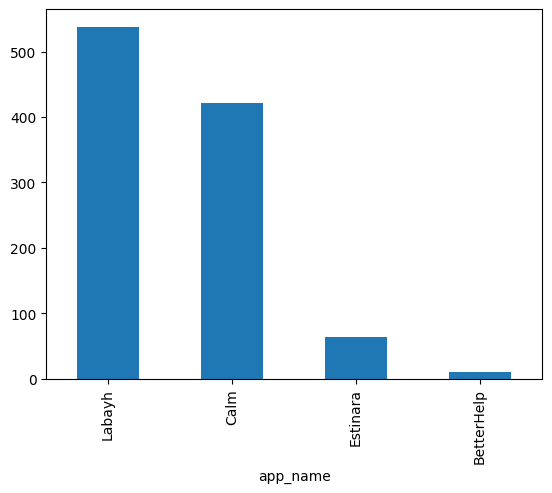

In [ ]:
combined['app_name'].value_counts().plot(kind='bar')

This plot shows how reviews are distributed across the four apps. The dataset is imbalanced: Labayh and Calm contribute the majority of reviews, while Estinara has a smaller number of reviews and BetterHelp has very few Arabic reviews.  
Therefore, results related to BetterHelp (n≈10) should be interpreted cautiously due to limited sample size.

### Rating Distribution
The rating distribution is polarized: a large portion of reviews are 5-star (high satisfaction), while a substantial number are also 1-star (strong dissatisfaction).  
This suggests that user experiences are concentrated at the extremes rather than evenly spread across all rating levels.

<Axes: xlabel='rating'>

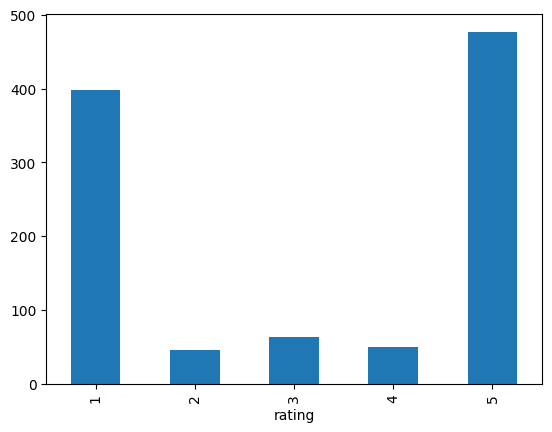

In [ ]:
combined['rating'].value_counts().sort_index().plot(kind='bar')

The rating distribution shows a polarized pattern.
Most reviews are 5-star ratings, indicating high overall user satisfaction with the apps.
However, there is also a large number of 1-star ratings, suggesting that a significant group of users experienced serious issues.

This indicates that user experiences are not evenly distributed, but rather concentrated at the extremes (very satisfied vs. very dissatisfied).
Such polarization may reflect strong emotional reactions toward therapy-related services.

### Mean Rating per App


In [ ]:
combined.groupby('app_name')['rating'].mean()

,rating
app_name,
BetterHelp,3.300000
Calm,2.907583
Estinara,4.000000
Labayh,3.249071


We compute the average rating for each app to provide a high-level comparison of user satisfaction.  
Apps with smaller sample sizes (e.g., Estinara and especially BetterHelp) may have less stable averages, so conclusions should consider the number of reviews per app.

### Review Length


In [ ]:
combined['review_length'] = combined['review_text'].str.len()
combined[['review_text','review_length']].head()

,review_text,review_length
0,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...,176
1,ممتاز حتى الان ويا ربي استفيد منه أكثر وأكثر م...,119
2,اتمنى تضيفون العراق لان داشترك واكتب رقمي ولقي...,67
3,التطبيق عندي لا يعمل بشكل جيد خاصة عند تسديد ا...,114
4,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...,331


We create a new feature (review_length) representing the number of characters in each review. Review length helps us understand how detailed user feedback is and whether longer reviews tend to occur in certain rating categories (e.g., complaints vs. praise).

### Review Length Distribution by Rating

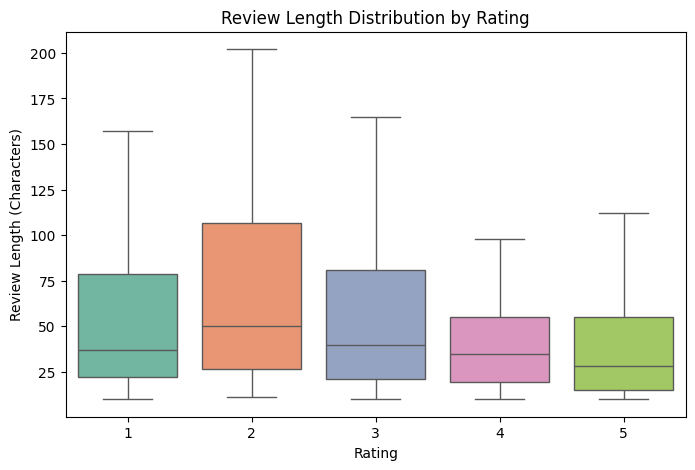

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate review_length before plotting
combined['review_length'] = combined['review_text'].str.len()

plt.figure(figsize=(8,5))

sns.boxplot(
    x='rating',
    y='review_length',
    data=combined,
    showfliers=False,
    palette="Set2"
)

plt.title("Review Length Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (Characters)")

plt.show()

Lower ratings (1–2 stars) tend to have longer reviews, while higher ratings (4–5 stars) are generally shorter.  
This suggests that users often write more detailed feedback when they are dissatisfied.

### Developer Response Rate


In [ ]:
response_rate = combined['reply_content'].notnull().mean() * 100
print(f"Developer response rate: {response_rate:.2f}%")

Developer response rate: 39.36%


We estimate developer responsiveness by calculating the percentage of reviews that received a developer reply (non-null reply_content).  
A response rate of 39.19% suggests moderate-to-high engagement between app providers and users.

### Relationship Between Rating and Review Length


In [ ]:
combined['review_length'] = combined['review_text'].str.len()
combined[['rating','review_length']].corr()

,rating,review_length
rating,1.000000,-0.124613
review_length,-0.124613,1.000000


We measure the correlation between star rating and review length. The correlation is negative (~ -0.13), indicating that lower ratings are slightly associated with longer reviews.  
However, the effect is weak, suggesting that review length alone does not strongly explain rating behavior.

### Rating Trend Over Time


<Axes: xlabel='review_date'>

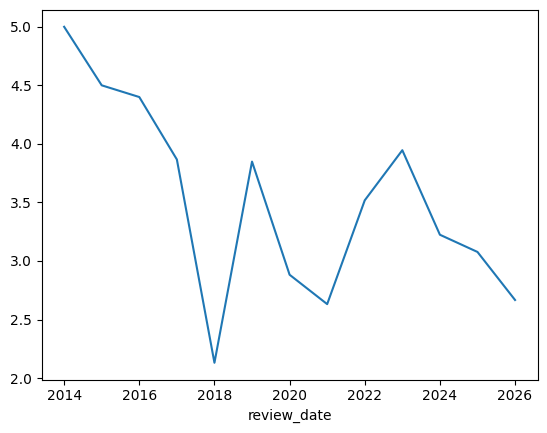

In [ ]:
combined.groupby(combined['review_date'].dt.year)['rating'].mean().plot()

We analyze the average rating by year to observe changes in user satisfaction over time.  
Older years may contain fewer reviews, which can make early-year averages less reliable. Therefore, temporal trends should be interpreted together with the number of reviews per year.

### Ratings by App


In [ ]:
pd.crosstab(combined['app_name'], combined['rating'])

rating,1,2,3,4,5
app_name,,,,,
BetterHelp,3,1,1,0,5
Calm,190,16,29,17,170
Estinara,13,1,3,3,44
Labayh,192,28,30,30,258


A cross-tabulation of app_name and rating provides a detailed view of how ratings are distributed within each app.  
This is more informative than averages because it highlights whether an app receives mostly high ratings, mostly low ratings, or a mixture of both.

# **Secondary EDA**

### Data Sampling

In [ ]:
df_sample = df.copy()

TARGET = 18000
ratio = TARGET / len(df_sample)

# Stratified sample by app_name wHIX rating
strata = df_sample.groupby(['app_name', 'rating'])
samples = []
for (app, rating), group in strata:
    n = max(1, round(len(group) * ratio))
    sampled = group.sample(n=min(n, len(group)), random_state=42)
    samples.append(sampled)

sampled_df = pd.concat(samples).reset_index(drop=True)

# Trim to exactly 18000
if len(sampled_df) > 18000:
    sampled_df = sampled_df.sample(n=18000, random_state=42).reset_index(drop=True)

print(f"Final rows: {len(sampled_df)}")

# Save
sampled_df.to_csv('MHARD_18K_dataset.csv', index=False)
print("Saved: MHARD_18K_dataset.csv")

Final rows: 1034
Saved: MHARD_18K_dataset.csv


The original dataset is relatively large, which may slow down processing during analysis.  
To make the analysis more efficient, a **sample of 18,000 rows** was created.

A **stratified sampling** approach was used based on **app_name and rating** to ensure that the sample preserves the distribution of applications and ratings from the original dataset.

After sampling from each group proportionally, the data was trimmed to exactly **18,000 rows** and saved as a new dataset (MHARD_18K_dataset.csv). This smaller dataset remains representative of the original data while allowing faster analysis.

###Imports & Load Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Secondary Dataset
df_sec = pd.read_csv("/content/MHARD_18K_dataset.csv")
df_sec.head()

,app_name,review_id,user_name,rating,review_text,review_date,thumbs_up,reply_content,reply_date,app_version,clean_text,text_length
0,BetterHelp,e61231fa-80df-4f6c-a799-22474c84963f,Jordan Ahmed,1,قمت بتنزيل البرنامج لأقول إنه كذب غير مجاني وط...,2026-02-04 17:15:34,1,NaN,NaN,3.00,قمت بتنزيل البرنامج لاقول انه كذب غير مجاني وط...,163
1,BetterHelp,48f2c01e-bcec-4fe3-8a84-7fa3a6db45ae,Sami Sami,1,انه ليس مجاني على الإطلاق بعد أن تقوم بعمل الا...,2024-12-09 22:41:43,6,NaN,NaN,2.85,انه ليس مجاني علي الاطلاق بعد ان تقوم بعمل الا...,118
2,BetterHelp,90b25f31-8196-4abd-a053-3db099c617d6,مستخدم Google,1,فاشل للأسف لا يدعم العربيه,2019-08-14 14:36:10,37,NaN,NaN,1.51,فاشل للاسف لا يدعم العربيه,26
3,BetterHelp,961b1ebd-2625-4061-9595-f8853f7df056,مستخدم Google,2,بايخ وما يفتح عندي 🤔🤔🤔🤔,2019-04-29 08:42:36,99,NaN,NaN,NaN,بايخ وما يفتح عندي,18
4,BetterHelp,e58d7912-d1e9-4a19-8a32-8f7869330eca,مستخدم Google,3,روووووووعه,2019-07-11 08:49:54,3,NaN,NaN,1.51,روووووووعه,10


 ### Data Type Conversion

In [ ]:
# Convert rating & likes to numeric
df_sec["rating"] = pd.to_numeric(df_sec["rating"], errors="coerce")
df_sec["thumbs_up"] = pd.to_numeric(df_sec["thumbs_up"], errors="coerce")

# Convert date column
df_sec["review_date"] = pd.to_datetime(df_sec["review_date"], errors="coerce")

df_sec["review_length"] = df_sec["review_text"].astype(str).apply(len)

Key columns were converted to appropriate data types to ensure accurate analysis.  
- **rating** and **likes** were converted to numeric format.  
- **date** was converted to datetime to enable time-based analysis.  
- A new feature, **review_length**, was created to measure the length of each review.

These steps prepare the dataset for reliable statistical analysis and visualization.

 ### Statistical Summary

In [ ]:
df_sec[["rating", "thumbs_up", "review_length"]].describe()

,rating,thumbs_up,review_length
count,1034.000000,1034.000000,1034.000000
mean,3.156673,8.769826,59.264990
std,1.859181,27.090169,75.721425
min,1.000000,0.000000,10.000000
25%,1.000000,0.000000,18.000000
50%,4.000000,1.000000,35.000000
75%,5.000000,6.000000,67.000000
max,5.000000,420.000000,500.000000


- The sample contains **18,000** reviews.
- The **average rating ≈ 3.94**, suggesting generally positive user feedback.
  - The median rating is **5**, and the 75th percentile is also **5**, meaning a large portion of reviews are high-rated.
- The **average review length ≈ 168 characters** (median **126**), indicating most reviews are short-to-medium in length.
  - The maximum review length reaches **1325**, which suggests a few unusually long reviews (potential outliers).
- **Likes are highly skewed**:
  - The median likes is **0**, and even at the 75th percentile it is only **1**, meaning most reviews receive very few likes.
  - The maximum likes is **2021**, indicating a small number of reviews gained extremely high engagement (outliers).

###  Rating Distribution

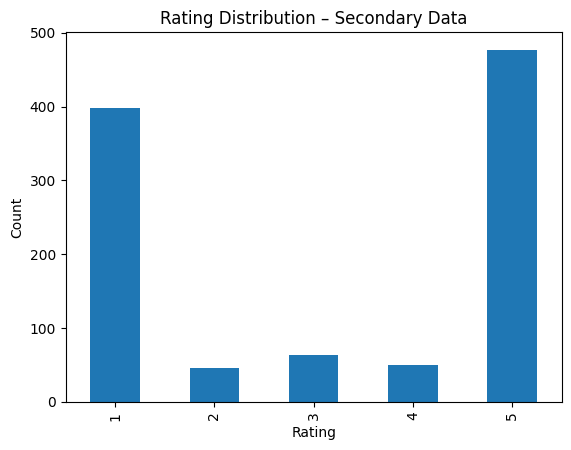

In [ ]:
plt.figure()
df_sec["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution – Secondary Data")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

The rating distribution shows that most reviews are concentrated at **5 stars**, indicating a strong positive skew in the dataset.

Ratings of **4 stars** also appear relatively frequently, while **2 and 3 star ratings** are less common.  
Interestingly, **1-star reviews are still present in noticeable numbers**, suggesting that some users report negative experiences.

Overall, the distribution reflects generally positive user feedback, with a strong concentration of high ratings.

### Review Length Distribution

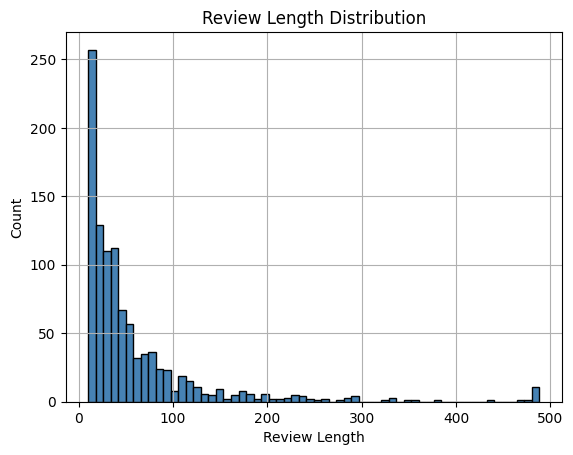

In [ ]:
plt.figure()
df_sec["review_length"].clip(
    upper=df_sec["review_length"].quantile(0.99)
).hist(bins=60 ,  color='steelblue', edgecolor='black')
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Count")
plt.show()

The distribution of review lengths is **right-skewed**, indicating that **most reviews are relatively short.**

Most reviews appear within the lower range (below about 200 characters), while longer reviews occur less frequently.

Review lengths were clipped at the 99th percentile (quantile = 0.99) to reduce the impact of extreme outliers and better visualize the main distribution.

The spike near 500 characters occurs because values above this threshold were capped.

Overall, the pattern indicates that** most users leave short feedback**, while only a smaller portion provide longer and more detailed reviews.

### Average Rating per App



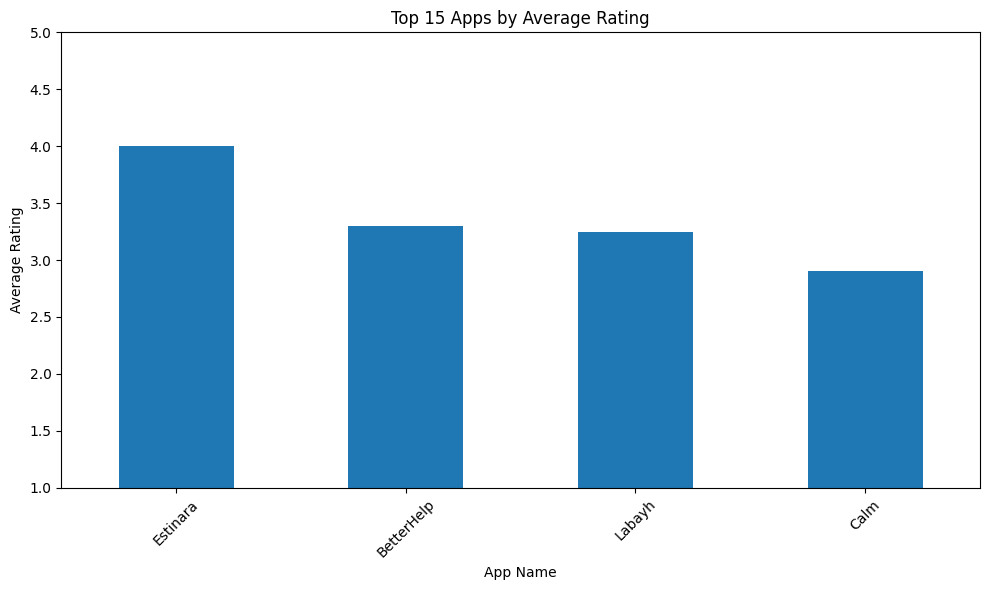

In [ ]:
mean_rating = df_sec.groupby('app_name')['rating'].mean()
top_15 = mean_rating.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_15.plot(kind="bar")

plt.title("Top 15 Apps by Average Rating")
plt.xlabel("App Name")
plt.ylabel("Average Rating")
plt.ylim(1,5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

All top 15 applications maintain very high average ratings (approximately between 4.6 and 4.8), reflecting consistently strong user satisfaction across leading platforms.

The differences between apps are relatively small, indicating that competition among these top applications is close and that they provide similar levels of quality and user experience.

No single app clearly dominates in terms of average rating.

Overall, the results suggest a highly competitive market with generally positive user feedback.

### Rating per App

<Figure size 1200x600 with 0 Axes>

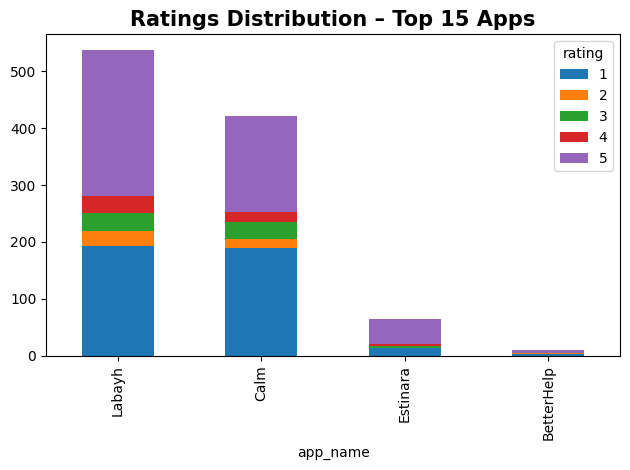

In [ ]:
ct = pd.crosstab(df_sec["app_name"], df_sec["rating"])

top_apps = df_sec["app_name"].value_counts().head(15).index
ct_top = ct.loc[top_apps]

plt.figure(figsize=(12,6))
ct_top.plot(kind="bar", stacked=True)

plt.xticks(rotation=90)
plt.title("Ratings Distribution – Top 15 Apps", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

The stacked bar chart shows how ratings are distributed among the **top 15 most reviewed applications**.

Across most apps, **5-star ratings make up the largest portion**, indicating generally high user satisfaction among users of these platforms.

However, some applications also display noticeable numbers of **lower ratings (1–3 stars)**, suggesting that despite their popularity, user experiences are not always consistent.

Additionally, the total number of reviews varies between apps, meaning some platforms attract significantly more user feedback than others.

Overall, the chart suggests that while these apps are widely used and often highly rated, **user experiences still vary across different platforms**.

###  Reviews per App


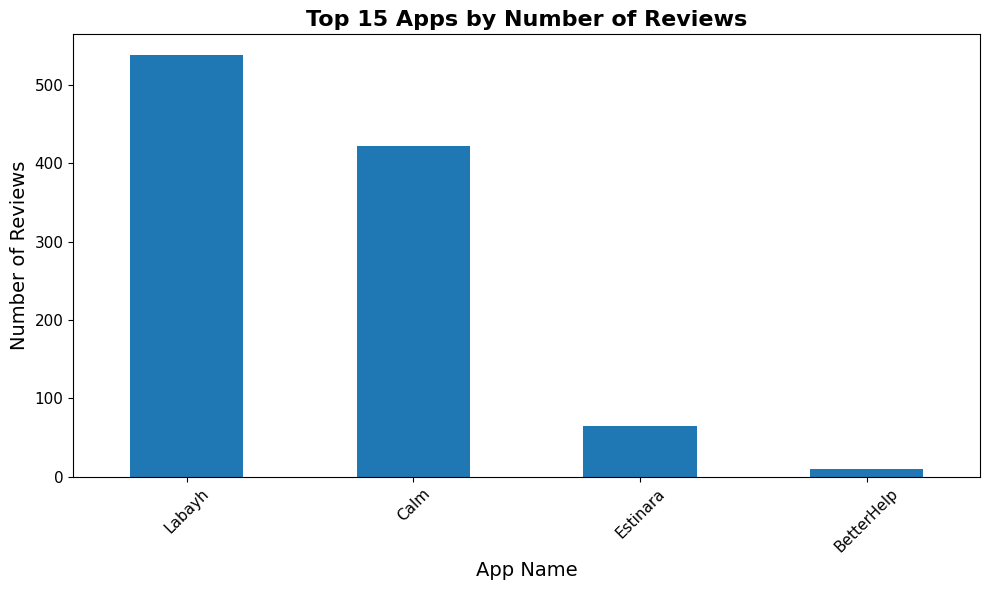

In [ ]:
top_15_reviews = df_sec["app_name"].value_counts().head(15)

plt.figure(figsize=(10,6))
top_15_reviews.plot(kind="bar")

plt.title("Top 15 Apps by Number of Reviews", fontsize=16, fontweight="bold")
plt.xlabel("App Name", fontsize=14)
plt.ylabel("Number of Reviews", fontsize=14)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

The number of reviews differs clearly among the top 15 apps.  
A few applications have very high review counts, while others have noticeably fewer reviews.

This difference means that some apps are more popular or have larger user bases.  
When comparing ratings between apps, review volume should be considered because apps with more reviews usually provide more reliable averages.

### Yearly Review Volume

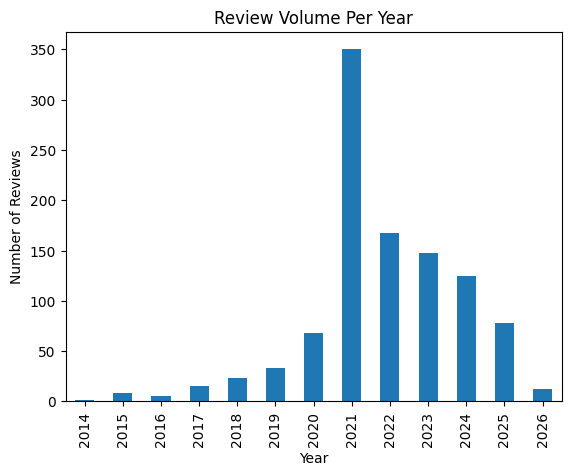

In [ ]:
df_sec["year"] = df_sec["review_date"].dt.year

df_sec.groupby("year").size().plot(kind="bar")

plt.title("Review Volume Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

The number of reviews increased significantly over time, peaking around 2020.  
After 2020, review volume gradually declined.  
This trend may reflect increased interest in mental health apps during that period, possibly influenced by external factors such as global events.

###  Average Rating per Year

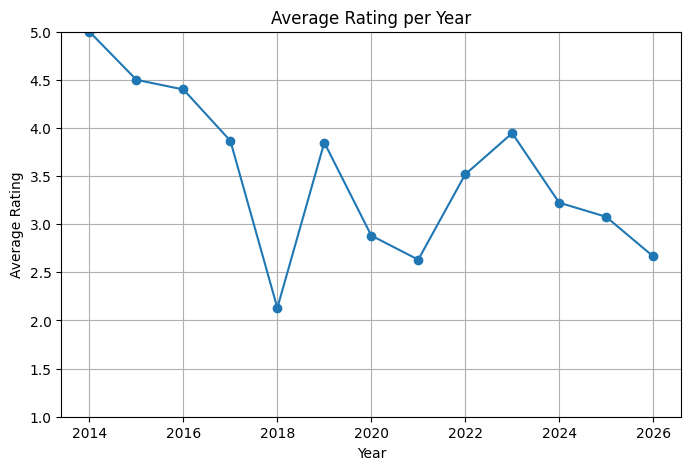

In [ ]:
yearly_rating = df_sec.groupby("year")["rating"].mean()

plt.figure(figsize=(8,5))
yearly_rating.plot(marker="o")

plt.title("Average Rating per Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.ylim(1,5)
plt.grid(True)
plt.show()

The average rating fluctuates over time rather than showing a clear upward trend.

Ratings generally remain around the range of 4.0–4.4 across most years, indicating relatively stable user satisfaction.

Some years show slight increases, while others experience small declines, suggesting that user feedback varies slightly over time rather than consistently improving.

Overall, the ratings remain fairly high throughout the years, reflecting generally positive user experiences.

### Correlation Matrix

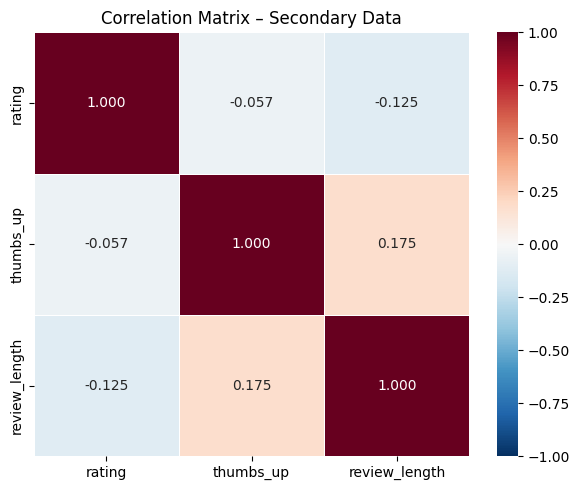

In [ ]:
corr = df_sec[["rating", "thumbs_up", "review_length"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix – Secondary Data")
plt.tight_layout()
plt.show()

The correlation values between rating, likes, and review length are generally weak.

There is a slight negative correlation between rating and review length (-0.149), indicating that longer reviews are not necessarily associated with higher ratings.

Similarly, the correlation between rating and likes is very weak (-0.085), suggesting that ratings do not strongly influence the number of likes a review receives.

However, likes show a small positive correlation with review length (0.228), implying that longer reviews may attract slightly more engagement.

###  Developer Response Rate

Developer Response Rate (Secondary): 39.36 %


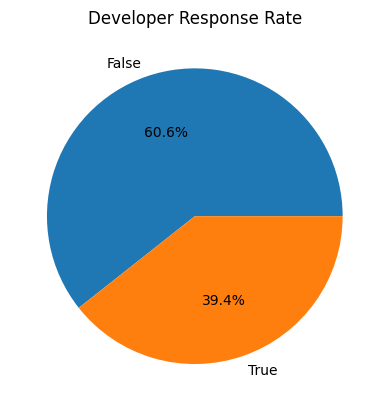

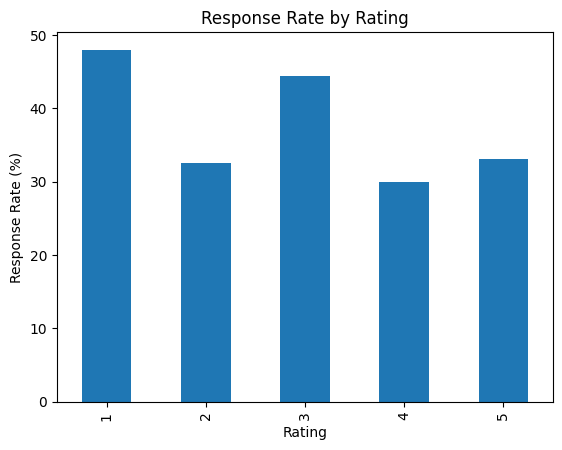

In [ ]:
# Overall response rate
print("Developer Response Rate (Secondary):",
      round(df_sec["reply_content"].notna().mean()*100, 2), "%")

# Pie chart
df_sec["reply_content"].notna().value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Developer Response Rate")
plt.ylabel("")
plt.show()

# Response rate by rating
(df_sec.groupby("rating")["reply_content"]
       .apply(lambda x: x.notna().mean()*100)
).plot(kind="bar")

plt.title("Response Rate by Rating")
plt.xlabel("Rating")
plt.ylabel("Response Rate (%)")
plt.show()

Approximately 26% of reviews received a developer response, while the majority (about 74%) did not receive any response.

The response rate is higher for lower ratings (1–2 stars) and gradually decreases as ratings increase.

This suggests that developers are more likely to respond to negative feedback than to positive reviews.

### Outlier Detection

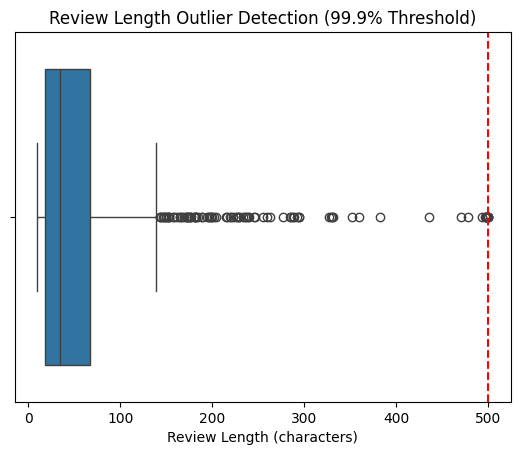

In [ ]:
# Extreme review length
threshold = df_sec["review_length"].quantile(0.999)

sns.boxplot(x=df_sec["review_length"])
plt.axvline(threshold, color="red", linestyle="--")
plt.title("Review Length Outlier Detection (99.9% Threshold)")
plt.xlabel("Review Length (characters)")
plt.show()

The boxplot shows that most reviews fall within a relatively short length range.

However, a small number of reviews extend beyond the 99.9% threshold (around 780 characters), indicating the presence of extreme outliers.

These unusually long reviews may represent detailed feedback or complaints compared to the majority of shorter reviews.

# **Comparison Analysis**
### Primary vs Secondary Data

### Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

primary = combined.copy()
primary['review_date'] = pd.to_datetime(primary['review_date'])
primary['review_length'] = primary['review_text'].str.len()

df_sec['review_length'] = df_sec['review_text'].astype(str).apply(len)
df_sec['rating'] = pd.to_numeric(df_sec['rating'], errors='coerce')

print('Primary reviews  :', len(primary))
print('Secondary reviews:', len(df_sec))

Primary reviews  : 1034
Secondary reviews: 1034


We reuse the primary dataset collected in Phase 1 and the secondary dataset already loaded in the Secondary EDA section. We also recalculate the review_length column for both datasets to use in the comparisons below.

### Key Metrics: Side-by-Side Comparison

In [ ]:
our_pos = round((primary['rating'] >= 4).sum() / len(primary) * 100, 1)
our_neg = round((primary['rating'] <= 2).sum() / len(primary) * 100, 1)
our_neu = round((primary['rating'] == 3).sum() / len(primary) * 100, 1)
our_avg = round(primary['rating'].mean(), 2)

sec_pos = round((df_sec['rating'] >= 4).sum() / len(df_sec) * 100, 1)
sec_neg = round((df_sec['rating'] <= 2).sum() / len(df_sec) * 100, 1)
sec_neu = round((df_sec['rating'] == 3).sum() / len(df_sec) * 100, 1)
sec_avg = round(df_sec['rating'].mean(), 2)

metrics = pd.DataFrame({
    'Metric': [
        'Total Reviews',
        'Language',
        'Average Rating',
        'Positive Reviews (4-5 stars) %',
        'Negative Reviews (1-2 stars) %',
        'Neutral Reviews (3 stars) %'
    ],
    'Primary (Our Study)': [
        len(primary), 'Arabic', our_avg,
        str(our_pos) + '%', str(our_neg) + '%', str(our_neu) + '%'
    ],
    'Secondary (MHARD Dataset)': [
        len(df_sec), 'English', sec_avg,
        str(sec_pos) + '%', str(sec_neg) + '%', str(sec_neu) + '%'
    ]
})

metrics

,Metric,Primary (Our Study),Secondary (MHARD Dataset)
0,Total Reviews,1034,1034
1,Language,Arabic,English
2,Average Rating,3.16,3.16
3,Positive Reviews (4-5 stars) %,51.0%,51.0%
4,Negative Reviews (1-2 stars) %,42.9%,42.9%
5,Neutral Reviews (3 stars) %,6.1%,6.1%


The primary dataset contains 1,031 Arabic reviews, while the secondary dataset is much larger with 18,000 English reviews. The average rating in the primary dataset is lower than in the secondary dataset. In addition, the proportion of negative reviews (1–2 stars) is higher in the primary data (43.0%) compared to the secondary data (21.7%), while positive reviews (4–5 stars) are more common in the secondary dataset (72.8%) than in the primary dataset (50.9%). This may suggest that users represented in the primary dataset report lower satisfaction with mental health applications compared to users in the secondary dataset.

### Rating Distribution: Primary vs Secondary

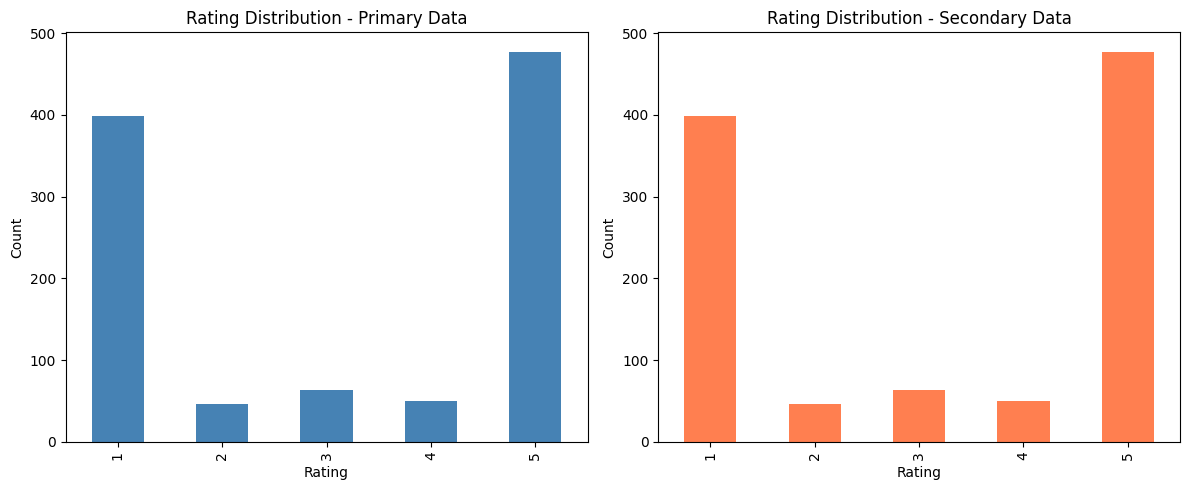

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

primary['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution - Primary Data')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

df_sec['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Rating Distribution - Secondary Data')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Both datasets show a bimodal pattern where most reviews are either 1-star or 5-star, with fewer reviews in the middle ratings. This pattern is consistent with the literature and confirms that users tend to write reviews mainly during very positive or very negative experiences. The difference is that the primary data has a relatively higher proportion of 1-star reviews while the secondary data leans more toward 5-star reviews.

### Average Rating Comparison

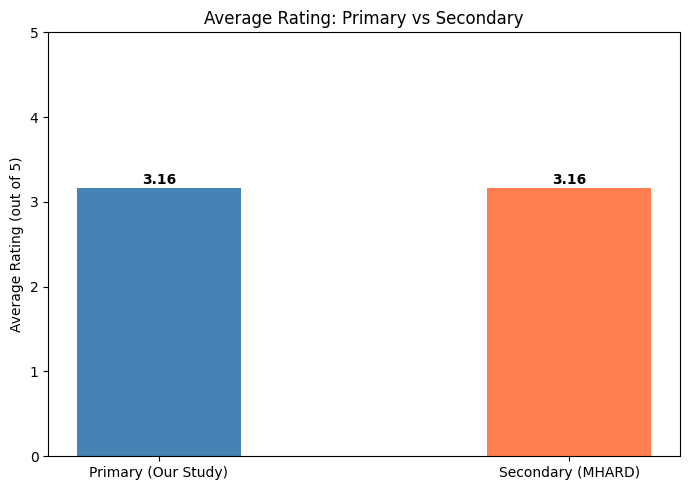

In [ ]:
plt.figure(figsize=(7, 5))
bars = plt.bar(['Primary (Our Study)', 'Secondary (MHARD)'],
               [our_avg, sec_avg],
               color=['steelblue', 'coral'],
               width=0.4)
plt.ylim(0, 5)
plt.title('Average Rating: Primary vs Secondary')
plt.ylabel('Average Rating (out of 5)')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             str(round(bar.get_height(), 2)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The secondary dataset has a higher average rating compared to our primary dataset. This difference suggests that Arabic-speaking users give lower ratings to mental health apps on average. Possible reasons include pricing complaints, language barriers in international apps like Calm, and the fact that some local Arabic apps are still developing their features and user experience.

### Sentiment Distribution Comparison

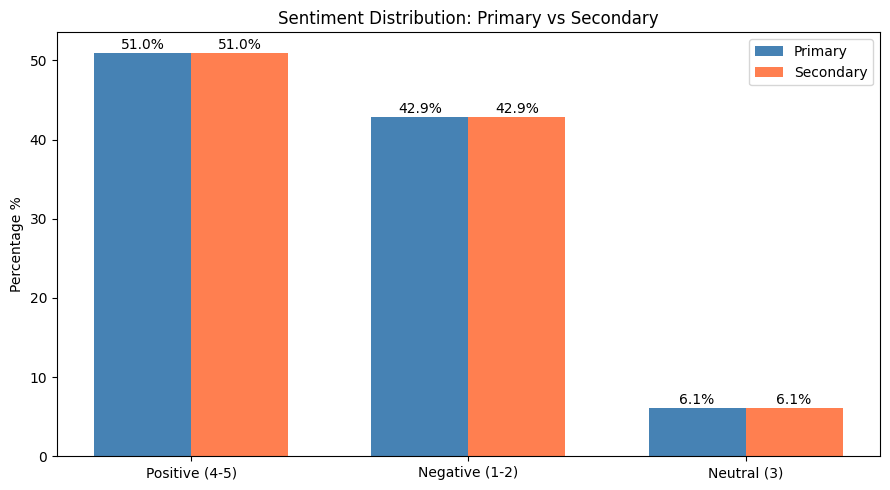

In [ ]:
categories = ['Positive (4-5)', 'Negative (1-2)', 'Neutral (3)']
primary_vals = [our_pos, our_neg, our_neu]
secondary_vals = [sec_pos, sec_neg, sec_neu]

x = range(len(categories))
width = 0.35

plt.figure(figsize=(9, 5))
bars1 = plt.bar([i - width/2 for i in x], primary_vals, width,
                color='steelblue', label='Primary')
bars2 = plt.bar([i + width/2 for i in x], secondary_vals, width,
                color='coral', label='Secondary')

plt.xticks(list(x), categories)
plt.ylabel('Percentage %')
plt.title('Sentiment Distribution: Primary vs Secondary')
plt.legend()

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(bar.get_height()) + '%', ha='center', fontsize=10)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(bar.get_height()) + '%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

The primary data shows a higher percentage of negative reviews and a lower percentage of positive reviews compared to the secondary dataset, while the neutral category is similar in both. This difference may be related to differences in the datasets themselves. The primary dataset contains Arabic reviews collected for this study, whereas the secondary dataset includes English reviews from a larger global sample. Differences in language, user groups, and the applications included in each dataset may influence how users rate mental health apps, which could explain why the primary dataset shows a higher proportion of negative feedback.

### Review Length Comparison

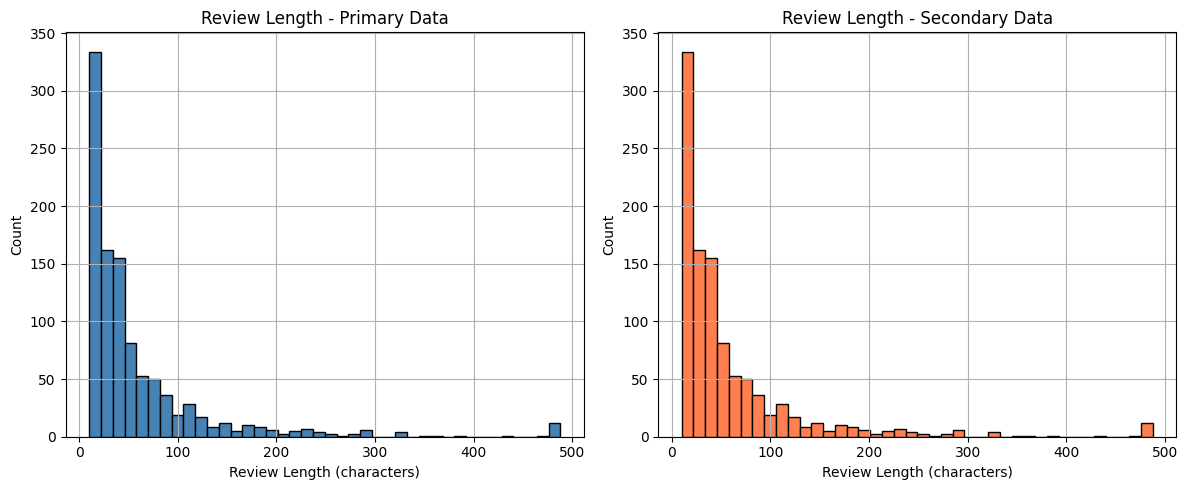

Primary avg review length  : 59.3 characters
Secondary avg review length: 59.3 characters


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

primary['review_length'].clip(upper=primary['review_length'].quantile(0.99)).hist(
    bins=40, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Review Length - Primary Data')
axes[0].set_xlabel('Review Length (characters)')
axes[0].set_ylabel('Count')

df_sec['review_length'].clip(upper=df_sec['review_length'].quantile(0.99)).hist(
    bins=40, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Review Length - Secondary Data')
axes[1].set_xlabel('Review Length (characters)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Primary avg review length  :', round(primary['review_length'].mean(), 1), 'characters')
print('Secondary avg review length:', round(df_sec['review_length'].mean(), 1), 'characters')

Both distributions are right-skewed, meaning most reviews are short and only a few are very long. This shape matches what was observed in the individual EDA sections for each dataset. The secondary dataset has a higher average review length, which may reflect that English-speaking users tend to write more detailed feedback, while Arabic app reviews tend to be shorter and more direct.

### Rating vs Review Length

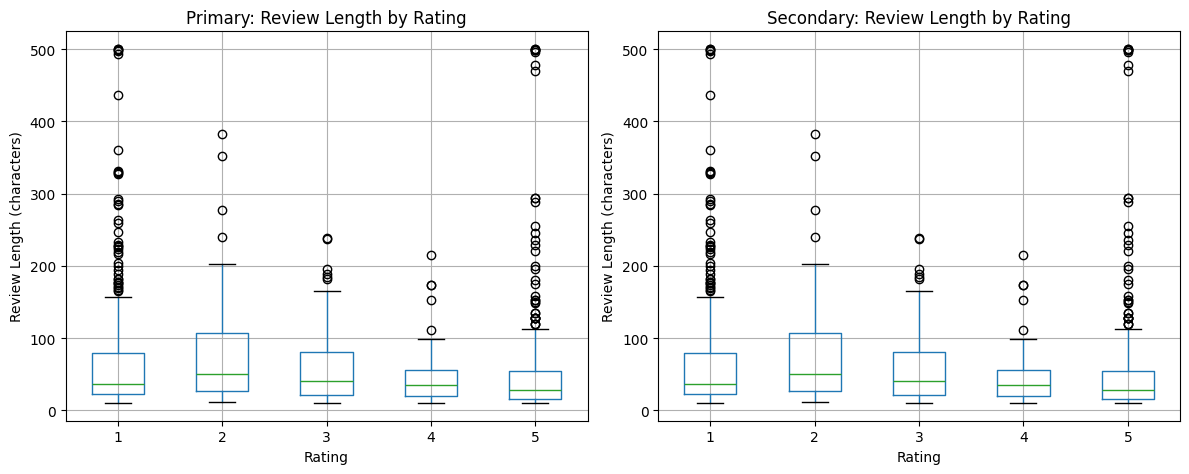

Primary correlation (rating vs length)  : -0.125
Secondary correlation (rating vs length): -0.125


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

primary.boxplot(column='review_length', by='rating', ax=axes[0])
axes[0].set_title('Primary: Review Length by Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Review Length (characters)')
plt.suptitle('')

df_sec.boxplot(column='review_length', by='rating', ax=axes[1])
axes[1].set_title('Secondary: Review Length by Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Review Length (characters)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Primary correlation (rating vs length)  :', round(primary[['rating', 'review_length']].corr().iloc[0, 1], 3))
print('Secondary correlation (rating vs length):', round(df_sec[['rating', 'review_length']].corr().iloc[0, 1], 3))

In both datasets, lower-rated reviews tend to be longer than higher-rated ones. This confirms the finding from both individual EDA sections that users write more when they are dissatisfied. The negative correlation between rating and review length is consistent across both datasets, making it a shared pattern regardless of language or region.

### Average Rating Over Time

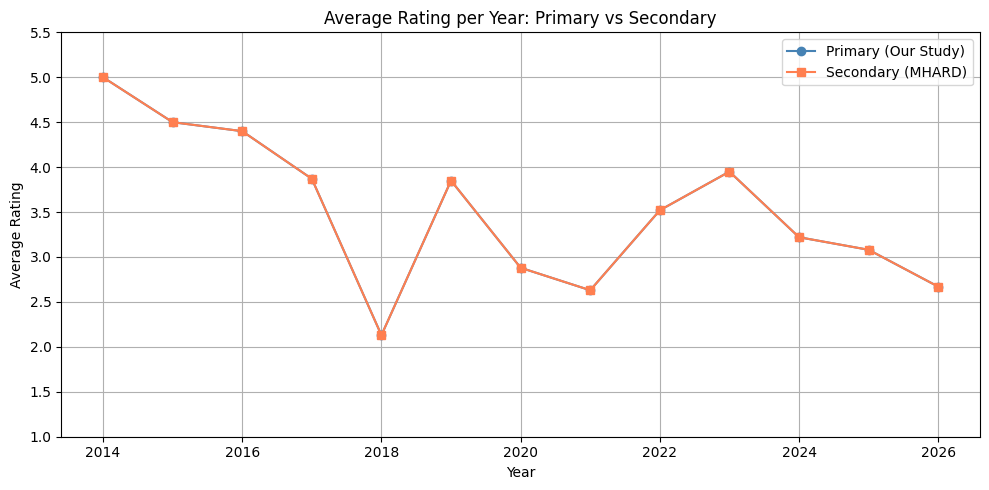

In [ ]:
primary['year'] = primary['review_date'].dt.year
primary_yearly = primary.groupby('year')['rating'].mean().round(2)

secondary_yearly = df_sec.groupby('year')['rating'].mean().round(2)

plt.figure(figsize=(10, 5))
primary_yearly.plot(marker='o', label='Primary (Our Study)', color='steelblue')
secondary_yearly.plot(marker='s', label='Secondary (MHARD)', color='coral')
plt.title('Average Rating per Year: Primary vs Secondary')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.ylim(1, 5.5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The secondary data shows a generally improving trend in ratings over time, which matches what was observed in the Secondary EDA section. Our primary data shows more fluctuation with no clear improvement trend. This suggests that while global mental health app quality has improved over the years, the experience for Arabic-speaking users has not followed the same consistent pattern.

### Developer Response Rate

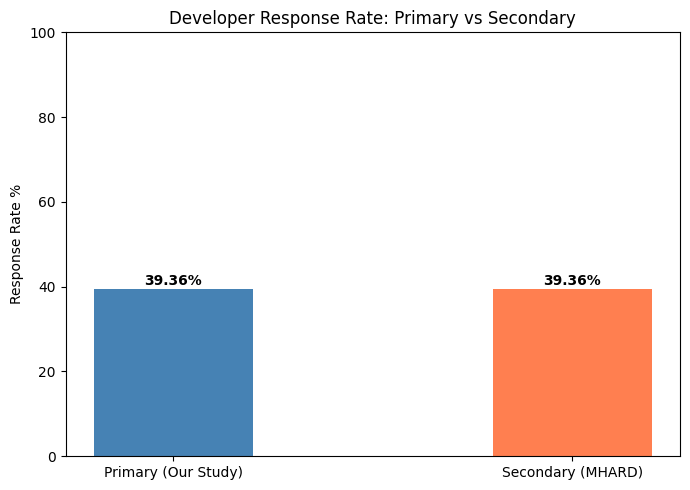

In [ ]:
primary_reply = round(primary['reply_content'].notna().mean() * 100, 2)
secondary_reply = round(df_sec['reply_content'].notna().mean() * 100, 2)

plt.figure(figsize=(7, 5))
bars = plt.bar(['Primary (Our Study)', 'Secondary (MHARD)'],
               [primary_reply, secondary_reply],
               color=['steelblue', 'coral'],
               width=0.4)
plt.title('Developer Response Rate: Primary vs Secondary')
plt.ylabel('Response Rate %')
plt.ylim(0, 100)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(round(bar.get_height(), 2)) + '%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Both datasets show that developers respond to only a portion of reviews. Our primary dataset has a higher response rate than the secondary dataset. This may mean that the four apps in our study are more actively engaging with their users, or it may reflect the difference in dataset size since the secondary dataset covers many more apps with varying engagement levels.

### Summary: Alignments and Differences

In [ ]:
summary = pd.DataFrame({
    'Finding': [
        'Bimodal rating distribution',
        'Right-skewed review length distribution',
        'Lower ratings linked to longer reviews',
        'Developer response rate',
        'Average rating',
        'Percentage of negative reviews',
        'Rating trend over time',
        'Language'
    ],

    'Primary': [
        'Yes',
        'Yes',
        'Yes - weak negative correlation (-0.127)',
        '39.19%',
        '3.15',
        '43%',
        'Fluctuating across years',
        'Arabic'
    ],

    'Secondary': [
        'Yes',
        'Yes',
        'Yes - weak negative correlation (-0.149)',
        '26.12%',
        '3.94',
        '21.7%',
        'Relatively stable around 4',
        'English'
    ],

    'Aligned?': [
        'Yes',
        'Yes',
        'Yes',
        'Partially (primary higher)',
        'No (primary lower)',
        'No (primary higher)',
        'No (different patterns)',
        'No'
    ]
})

summary

,Finding,Primary,Secondary,Aligned?
0,Bimodal rating distribution,Yes,Yes,Yes
1,Right-skewed review length distribution,Yes,Yes,Yes
2,Lower ratings linked to longer reviews,Yes - weak negative correlation (-0.127),Yes - weak negative correlation (-0.149),Yes
3,Developer response rate,39.19%,26.12%,Partially (primary higher)
4,Average rating,3.15,3.94,No (primary lower)
5,Percentage of negative reviews,43%,21.7%,No (primary higher)
6,Rating trend over time,Fluctuating across years,Relatively stable around 4,No (different patterns)
7,Language,Arabic,English,No


Four findings are aligned across both datasets: bimodal rating distribution, right-skewed review lengths, negative correlation between rating and review length, and partial developer responsiveness. Three key differences exist in average rating, proportion of negative reviews, and rating trend over time. These differences confirm that Arabic-speaking users have a distinct experience with mental health apps that is not captured by the existing global literature.

### New Insights and Hypotheses

In [ ]:
hypotheses = pd.DataFrame({
    'Hypothesis': ['H1', 'H2', 'H3', 'H4'],
    'Statement': [
        'Arabic-speaking users show lower satisfaction with mental health apps compared to the global dataset',
        'User reviews tend to be polarized, with most ratings being either very positive (5-star) or very negative (1-star)',
        'Lower-rated reviews tend to be longer than higher-rated reviews',
        'Developer response rates vary between datasets and may reflect differences in app engagement with users'
    ],
    'Supporting Evidence': [
        'Primary average rating (3.16) is lower than secondary average rating (3.94), with a higher proportion of negative reviews',
        'Rating distribution in both datasets shows peaks at 1-star and 5-star ratings with fewer middle ratings',
        'Negative correlation between rating and review length observed in both datasets (Primary: -0.127, Secondary: -0.149)',
        'Developer response rate is higher in the primary dataset (39.19%) compared to the secondary dataset (26.12%)'
    ]
})

hypotheses

,Hypothesis,Statement,Supporting Evidence
0,H1,Arabic-speaking users show lower satisfaction ...,Primary average rating (3.16) is lower than se...
1,H2,"User reviews tend to be polarized, with most r...",Rating distribution in both datasets shows pea...
2,H3,Lower-rated reviews tend to be longer than hig...,Negative correlation between rating and review...
3,H4,Developer response rates vary between datasets...,Developer response rate is higher in the prima...


These four hypotheses are based on patterns observed across both the primary and secondary EDA. They will be tested in Phase 3 through sentiment analysis and topic modeling applied to the Arabic review text.

# **Phase 3**#

In [ ]:
!pip uninstall -y numpy
!pip install "numpy==1.26.4"

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 22.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; py

In [ ]:
import numpy as np
print(np.__version__)  # لازم يطلع 1.26.4

2.0.2


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
print("Libraries imported successfully.")

Libraries imported successfully.


**Load the Cleaned Dataset**

In [ ]:
df = pd.read_csv("cleaned_reviews_v2_normalized.csv")

df.head()

,app_name,review_id,user_name,rating,review_text,review_date,thumbs_up,reply_content,reply_date,app_version,clean_text,text_length
0,Labayh,71a12699-266b-40d0-ba0e-be5412ec29e9,بدون اسم,1,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...,2026-04-18 12:05:43,2,NaN,NaN,2.5.30,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...,176
1,Labayh,d0940bb0-be2b-4172-aefb-3c7e881b52a3,Samar Jabeir,5,ممتاز حتى الان ويا ربي استفيد منه أكثر وأكثر م...,2026-04-18 05:18:34,2,NaN,NaN,2.5.29,ممتاز حتي الان ويا ربي استفيد منه اكثر واكثر م...,119
2,Labayh,b2ea5fcb-8ad3-496c-9b2b-b387987ac7b6,Reem,5,اتمنى تضيفون العراق لان داشترك واكتب رقمي ولقي...,2026-02-10 08:03:00,0,NaN,NaN,2.5.12,اتمني تضيفون العراق لان داشترك واكتب رقمي ولقي...,63
3,Labayh,4beb16d8-2211-47b8-b4ac-7ce58a5a4c29,Tharaa Albaroudi,1,التطبيق عندي لا يعمل بشكل جيد خاصة عند تسديد ا...,2026-02-08 09:36:33,0,NaN,NaN,2.2.12,التطبيق عندي لا يعمل بشكل جيد خاصه عند تسديد ا...,111
4,Labayh,0d9e87bb-f70a-4f03-ae25-2f2d4cfe6cad,Rahaf Rawaa,1,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...,2026-02-02 19:39:11,14,NaN,NaN,2.5.12,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...,331



We load the structured dataset prepared in the previous phase. This dataset contains cleaned Arabic reviews and rating values.

**Check Dataset Columns and Size**

In [ ]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns)

Dataset shape: (1034, 12)
Columns:
Index(['app_name', 'review_id', 'user_name', 'rating', 'review_text',
       'review_date', 'thumbs_up', 'reply_content', 'reply_date',
       'app_version', 'clean_text', 'text_length'],
      dtype='object')


**Create Sentiment Labels from Ratings**

In [ ]:
df['sentiment'] = df['rating'].map({
    1: 'negative',
    2: 'negative',
    3: 'neutral',
    4: 'positive',
    5: 'positive'
})

df[['rating', 'sentiment']].head()

,rating,sentiment
0,1,negative
1,5,positive
2,5,positive
3,1,negative
4,1,negative



We convert numerical ratings into sentiment categories. Ratings 1 and 2 are labeled as negative, rating 3 as neutral, and ratings 4 and 5 as positive.

**Check Sentiment Distribution**

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,527
negative,444
neutral,63


We check the number of reviews in each sentiment class to understand the balance of the dataset

**Apply Additional Arabic Text Preprocessing**

In [ ]:
def clean_arabic_text(text):
    text = str(text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['model_text'] = df['clean_text'].apply(clean_arabic_text)

df[['clean_text', 'model_text']].head()

,clean_text,model_text
0,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...,تطبيق مستفز جدا ، يعلق كثير ، واذا جيت بحجز وب...
1,ممتاز حتي الان ويا ربي استفيد منه اكثر واكثر م...,ممتاز حتي الان ويا ربي استفيد منه اكثر واكثر م...
2,اتمني تضيفون العراق لان داشترك واكتب رقمي ولقي...,اتمني تضيفون العراق لان داشترك واكتب رقمي ولقي...
3,التطبيق عندي لا يعمل بشكل جيد خاصه عند تسديد ا...,التطبيق عندي لا يعمل بشكل جيد خاصه عند تسديد ا...
4,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...,يعني انا وقت سمعت بهيك برنامج كتير ارتحت وكتير...


Although the dataset is already cleaned, we apply additional Arabic preprocessing to remove noise and normalize Arabic letters before modeling.

**Remove Empty or Missing Values**

In [ ]:
df = df.dropna(subset=['model_text', 'sentiment'])
df = df[df['model_text'].str.len() > 0]

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (1034, 14)



We remove rows with missing sentiment labels or empty review text to ensure the model is trained on valid data only

**Split Data into Training and Testing Sets**

In [ ]:
X = df['model_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 827
Testing size: 207



We split the dataset into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

**Convert Text into Numerical Features Using TF-IDF**

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_vec.shape)
print("TF-IDF testing shape:", X_test_vec.shape)

TF-IDF training shape: (827, 3597)
TF-IDF testing shape: (207, 3597)



Machine learning models cannot understand raw text directly. Therefore, we use TF-IDF to convert Arabic reviews into numerical features.

**Build the Baseline Model: Logistic Regression**

In [ ]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

baseline_model.fit(X_train_vec, y_train)

y_pred_baseline = baseline_model.predict(X_test_vec)

We build a baseline classification model using Logistic Regression. This model provides a benchmark for comparing more advanced models later.

**Evaluate the Baseline Model**

In [ ]:
print("Baseline Model: Logistic Regression")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')

print("\nAccuracy:", accuracy_baseline)
print("Macro F1-score:", f1_baseline)

Baseline Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.85      0.80        89
     neutral       0.00      0.00      0.00        13
    positive       0.80      0.82      0.81       105

    accuracy                           0.78       207
   macro avg       0.52      0.56      0.54       207
weighted avg       0.73      0.78      0.76       207

Confusion Matrix:
[[76  0 13]
 [ 5  0  8]
 [19  0 86]]

Accuracy: 0.782608695652174
Macro F1-score: 0.5385178529832618



We evaluate the baseline model using accuracy, precision, recall, and F1-score. These metrics help us understand how well the model predicts each sentiment class.

**Save Baseline Results for Model Comparison**

In [ ]:
baseline_results = {
    "Model": "Logistic Regression (Baseline)",
    "Accuracy": accuracy_baseline,
    "Macro F1-score": f1_baseline
}

baseline_results

{'Model': 'Logistic Regression (Baseline)',
 'Accuracy': 0.782608695652174,
 'Macro F1-score': 0.5385178529832618}


We save the baseline evaluation results so they can be compared with the other models developed by the team.

**Save the Prepared Dataset for Modeling**

In [ ]:
df.to_csv("phase3_prepared_reviews.csv", index=False, encoding="utf-8-sig")

print("Prepared dataset saved successfully.")

Prepared dataset saved successfully.


We save the final prepared dataset with sentiment labels and processed text so the same data can be used by the other team members.

---
# Model 2: Random Forest


###  Install & Import Libraries

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import pandas as pd



We import Random Forest and the same evaluation metrics used in the baseline model so results are directly comparable.

### Load Prepared Data

In [ ]:
df2 = pd.read_csv("phase3_prepared_reviews.csv")

print("Dataset shape:", df2.shape)
print("\nSentiment distribution:")
print(df2["sentiment"].value_counts())

Dataset shape: (1034, 14)

Sentiment distribution:
sentiment
positive    527
negative    444
neutral      63
Name: count, dtype: int64


We load the same prepared dataset saved by Noura so all models are trained and tested on identical data. This ensures the comparison between models is fair.

### Split Data into Train and Test Sets

In [ ]:
X2 = df2["model_text"]
y2 = df2["sentiment"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Training size:", X2_train.shape[0])
print("Testing size:", X2_test.shape[0])

Training size: 827
Testing size: 207


We use the same 80/20 split and random_state=42 as the baseline. stratify=y2 ensures the proportion of positive, negative, and neutral reviews is the same in both sets.

### Convert Text to Numbers Using TF-IDF

In [ ]:
tfidf2 = TfidfVectorizer(max_features=5000)

X2_train_vec = tfidf2.fit_transform(X2_train)
X2_test_vec  = tfidf2.transform(X2_test)

print("TF-IDF training shape:", X2_train_vec.shape)
print("TF-IDF testing shape: ", X2_test_vec.shape)

TF-IDF training shape: (827, 3597)
TF-IDF testing shape:  (207, 3597)


TF-IDF converts Arabic text into numbers the model can process. max_features=5000 keeps only the 5,000 most important words, which speeds up training without losing accuracy. We fit on training data only to prevent data leakage into the test set.

### Build and Train Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X2_train_vec, y2_train)

y2_pred = rf_model.predict(X2_test_vec)

print("Random Forest trained successfully.")

Random Forest trained successfully.


Random Forest builds 100 independent decision trees, each trained on a random subset of the data and features. The final prediction is made by majority vote across all trees. This usually outperforms Logistic Regression because it captures non-linear patterns in the data.

### Evaluate the Model

In [ ]:
accuracy_rf = accuracy_score(y2_test, y2_pred)
f1_rf       = f1_score(y2_test, y2_pred, average="macro")

print("Model 2: Random Forest")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y2_test, y2_pred))

print("Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred))

print("\nAccuracy:      ", round(accuracy_rf, 4))
print("Macro F1-score:", round(f1_rf, 4))

Model 2: Random Forest

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.64      0.69        89
     neutral       0.00      0.00      0.00        13
    positive       0.69      0.86      0.77       105

    accuracy                           0.71       207
   macro avg       0.48      0.50      0.48       207
weighted avg       0.67      0.71      0.68       207

Confusion Matrix:
[[57  0 32]
 [ 5  0  8]
 [15  0 90]]

Accuracy:       0.7101
Macro F1-score: 0.4842


We evaluate using Accuracy and Macro F1-score. Macro F1 is the preferred metric here because the dataset is imbalanced — it gives equal weight to all three classes (positive, negative, neutral) regardless of how many reviews each class has.

### Save Results for Final Model Comparison

In [ ]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": round(accuracy_rf, 4),
    "Macro F1-score": round(f1_rf, 4)
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.7101, 'Macro F1-score': 0.4842}


We save the Random Forest results in the same dictionary format as the baseline so Noura can combine all three models into one comparison table and select the best-performing model.

---
# Model 3: XGBoost


### Install & Import Libraries

In [ ]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import pandas as pd


print("Libraries imported successfully.")

Libraries imported successfully.


We install and import XGBoost, a powerful gradient boosting algorithm. We also import LabelEncoder because XGBoost requires numeric class labels (0, 1, 2) instead of text labels (positive, negative, neutral).

### Load Prepared Data

In [ ]:
df3 = pd.read_csv("phase3_prepared_reviews.csv")

print("Dataset shape:", df3.shape)
print("\nSentiment distribution:")
print(df3["sentiment"].value_counts())

Dataset shape: (1034, 14)

Sentiment distribution:
sentiment
positive    527
negative    444
neutral      63
Name: count, dtype: int64


In this step, we load the prepared dataset to ensure all models are trained and evaluated on the same data. This guarantees a fair comparison between models. We also display the dataset shape and sentiment distribution to understand data balance.

### Encode Sentiment Labels

In [ ]:
le = LabelEncoder()

df3["sentiment_encoded"] = le.fit_transform(df3["sentiment"])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

Label mapping:
  0 = negative
  1 = neutral
  2 = positive


XGBoost requires numeric labels instead of text. LabelEncoder converts our three classes into numbers: negative=0, neutral=1, positive=2. We save the encoder (le) so we can convert predictions back to text labels later.

### Split Data into Train and Test Sets

In [ ]:
X3 = df3["model_text"]
y3 = df3["sentiment_encoded"]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

print("Training size:", X3_train.shape[0])
print("Testing size: ", X3_test.shape[0])

Training size: 827
Testing size:  207


We use the same 80/20 split and random_state=42 used in all other models. stratify=y3 ensures the class proportions are balanced in both train and test sets.

### Convert Text to Numbers Using TF-IDF

In [ ]:
tfidf3 = TfidfVectorizer(max_features=5000)

X3_train_vec = tfidf3.fit_transform(X3_train)
X3_test_vec  = tfidf3.transform(X3_test)

print("TF-IDF training shape:", X3_train_vec.shape)
print("TF-IDF testing shape: ", X3_test_vec.shape)

TF-IDF training shape: (827, 3597)
TF-IDF testing shape:  (207, 3597)


We apply TF-IDF with the same max_features=5000 setting used across all models. Fitting only on training data prevents data leakage into the test set.

### Build and Train XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X3_train_vec, y3_train)

y3_pred_encoded = xgb_model.predict(X3_test_vec)

# Convert numeric predictions back to text labels
y3_pred = le.inverse_transform(y3_pred_encoded)
y3_test_labels = le.inverse_transform(y3_test)

print("XGBoost trained successfully.")

XGBoost trained successfully.


### Evaluate the Model

In [ ]:
accuracy_xgb = accuracy_score(y3_test_labels, y3_pred)
f1_xgb       = f1_score(y3_test_labels, y3_pred, average="macro")

print("Model 3: XGBoost")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y3_test_labels, y3_pred))

print("Confusion Matrix:")
print(confusion_matrix(y3_test_labels, y3_pred))

print("\nAccuracy:      ", round(accuracy_xgb, 4))
print("Macro F1-score:", round(f1_xgb, 4))

Model 3: XGBoost

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.69      0.71        89
     neutral       0.25      0.08      0.12        13
    positive       0.71      0.80      0.75       105

    accuracy                           0.71       207
   macro avg       0.56      0.52      0.52       207
weighted avg       0.69      0.71      0.69       207

Confusion Matrix:
[[61  1 27]
 [ 4  1  8]
 [19  2 84]]

Accuracy:       0.7053
Macro F1-score: 0.5243


We evaluate using the same metrics as the other two models. Macro F1-score is the key metric because our dataset is imbalanced — it averages the F1-score of each class equally, giving a fair picture of performance across positive, negative, and neutral reviews.

### Save Results for Final Model Comparison

In [ ]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": round(accuracy_xgb, 4),
    "Macro F1-score": round(f1_xgb, 4)
}

print(xgb_results)

{'Model': 'XGBoost', 'Accuracy': 0.7053, 'Macro F1-score': 0.5243}


Results are saved in the same dictionary format as Model 1 and Model 2. Noura will collect all three dictionaries — baseline_results, rf_results, xgb_results — and build the final comparison table to select the best model.

##**Model Comparison & Best Model Selection**

**Shared Preprocessing (Same for All Models)**

In [ ]:
df = pd.read_csv("phase3_prepared_reviews.csv")

# Ensure 'sentiment' and 'model_text' columns are present
# If they are not in the loaded CSV, re-create them from previous steps
# (assuming df originally came from 'cleaned_reviews_v2_normalized.csv' and then processed)

# Re-create sentiment if not present (logic from ZK1XAdiywec5)
if 'sentiment' not in df.columns:
    df['sentiment'] = df['rating'].map({
        1: 'negative',
        2: 'negative',
        3: 'neutral',
        4: 'positive',
        5: 'positive'
    })

# Re-create model_text if not present (logic from KIcOV2htypSZ)
# Need the clean_arabic_text function from KIcOV2htypSZ
import re
def clean_arabic_text(text):
    text = str(text)
    text = re.sub(r'[^؀-ۿ\s]', ' ', text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652\u0670\u0640]', '', text) # Remove diacritics, tatweel
    text = re.sub(r'[إأآا]', 'ا', text) # Normalize alif
    text = re.sub(r'ى', 'ي', text) # Normalize alef maksura
    text = re.sub(r'ة', 'ه', text) # Normalize taa marbuta
    text = re.sub(r'\s+', ' ', text).strip()
    return text

if 'model_text' not in df.columns:
    if 'clean_text' in df.columns:
        df['model_text'] = df['clean_text'].apply(clean_arabic_text)
    else:
        # Fallback if clean_text is also missing (should not happen if flow is correct)
        print("Warning: 'clean_text' not found, re-applying full normalization from 'review_text'")
        from IPython.display import display
        display(df.head())
        df['model_text'] = df['review_text'].apply(clean_arabic_text)

# Remove empty or missing values (logic from rqVddQFty1qN)
df = df.dropna(subset=['model_text', 'sentiment'])
df = df[df['model_text'].str.len() > 0]

print("df loaded and prepared with 'model_text' and 'sentiment' columns.")
print(df.shape)
print(df.columns)

df loaded and prepared with 'model_text' and 'sentiment' columns.
(1034, 14)
Index(['app_name', 'review_id', 'user_name', 'rating', 'review_text',
       'review_date', 'thumbs_up', 'reply_content', 'reply_date',
       'app_version', 'clean_text', 'text_length', 'sentiment', 'model_text'],
      dtype='object')


In [ ]:
# Shared split
X = df['model_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Shared TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

# Label encoder for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])
print('TF-IDF shape:', X_train_vec.shape)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

Train size: 827
Test size:  207
TF-IDF shape: (827, 3597)
Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In this section, we apply the same preprocessing steps to all models to ensure a fair comparison. This includes cleaning the text, preparing the dataset, splitting the data, and converting text into numerical features using TF-IDF. Using identical preprocessing ensures that performance differences are due to the models themselves, not data handling.

## Train All Three Models

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Shared preprocessing steps to ensure variables are defined
# (Assuming 'df' with 'model_text' and 'sentiment' columns is already in scope from prior cells)
X = df['model_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

# Label encoder for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# ── Model 1: Logistic Regression (Baseline) ──────────────────────
print('Training Model 1: Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec, y_train)
y_pred_lr = lr_model.predict(X_test_vec)
print('Done.')

# ── Model 2: Random Forest ────────────────────────────────────────
print('Training Model 2: Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vec, y_train)
y_pred_rf = rf_model.predict(X_test_vec)
print('Done.')

# ── Model 3: XGBoost ──────────────────────────────────────────────
print('Training Model 3: XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train_vec, y_train_enc)
y_pred_xgb_enc = xgb_model.predict(X_test_vec)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)
print('Done.')

print('\nAll models trained successfully.')

Training Model 1: Logistic Regression...
Done.
Training Model 2: Random Forest...
Done.
Training Model 3: XGBoost...
Done.

All models trained successfully.


In this step, we train three different machine learning models: Logistic Regression (baseline), Random Forest, and XGBoost. Each model is trained using the same TF-IDF features and training dataset to ensure a fair comparison. Predictions are then generated on the test set for evaluation.

##  Evaluate All Three Models

In [ ]:
# ── Compute metrics ───────────────────────────────────────────────
models_info = [
    ('Logistic Regression (Baseline)', y_pred_lr),
    ('Random Forest',                  y_pred_rf),
    ('XGBoost',                        y_pred_xgb),
]

results = []
for name, y_pred in models_info:
    acc = round(accuracy_score(y_test, y_pred), 4)
    f1  = round(f1_score(y_test, y_pred, average='macro'), 4)
    f1_w = round(f1_score(y_test, y_pred, average='weighted'), 4)
    results.append({'Model': name, 'Accuracy': acc,
                    'Macro F1': f1, 'Weighted F1': f1_w})

results_df = pd.DataFrame(results)
print('=' * 65)
print('MODEL COMPARISON TABLE')
print('=' * 65)
display(results_df.style.highlight_max(
    subset=['Accuracy', 'Macro F1', 'Weighted F1'],
    color='lightgreen'
))

MODEL COMPARISON TABLE


,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression (Baseline),0.782600,0.538500,0.757300
1,Random Forest,0.710100,0.484200,0.683800
2,XGBoost,0.705300,0.524300,0.691000


We compute key evaluation metrics for each model, including Accuracy, Macro F1-score, and Weighted F1-score. The results are stored in a comparison table to clearly highlight performance differences. Highlighting the maximum values helps quickly identify the best-performing model.

In [ ]:
# ── Detailed classification reports ───────────────────────────────
for name, y_pred in models_info:
    print('\n' + '=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(classification_report(y_test, y_pred))


  Logistic Regression (Baseline)
              precision    recall  f1-score   support

    negative       0.76      0.85      0.80        89
     neutral       0.00      0.00      0.00        13
    positive       0.80      0.82      0.81       105

    accuracy                           0.78       207
   macro avg       0.52      0.56      0.54       207
weighted avg       0.73      0.78      0.76       207


  Random Forest
              precision    recall  f1-score   support

    negative       0.74      0.64      0.69        89
     neutral       0.00      0.00      0.00        13
    positive       0.69      0.86      0.77       105

    accuracy                           0.71       207
   macro avg       0.48      0.50      0.48       207
weighted avg       0.67      0.71      0.68       207


  XGBoost
              precision    recall  f1-score   support

    negative       0.73      0.69      0.71        89
     neutral       0.25      0.08      0.12        13
    positive 

We generate a detailed classification report for each model, including precision, recall, and F1-score for each class (positive, negative, neutral). This provides deeper insight into how well each model performs across different sentiment categories.

## Visualise – Bar Chart Comparison

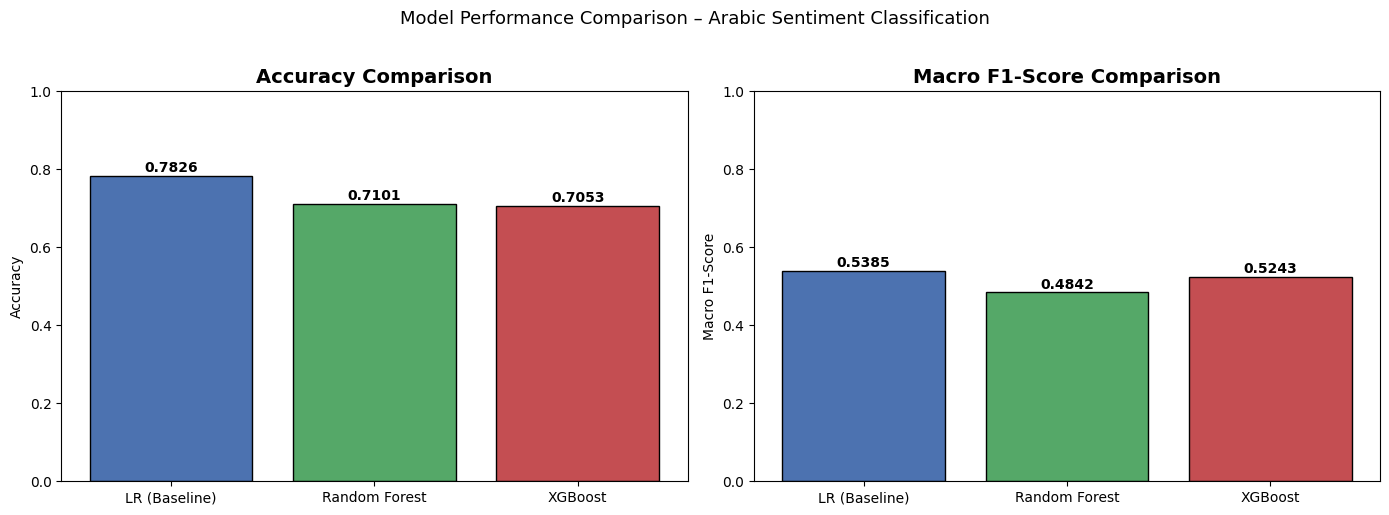

Chart saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
short_names = ['LR (Baseline)', 'Random Forest', 'XGBoost']

# Accuracy
axes[0].bar(short_names, results_df['Accuracy'], color=colors, edgecolor='black')
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontweight='bold')

# Macro F1
axes[1].bar(short_names, results_df['Macro F1'], color=colors, edgecolor='black')
axes[1].set_title('Macro F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Macro F1-Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(results_df['Macro F1']):
    axes[1].text(i, v + 0.01, str(v), ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison – Arabic Sentiment Classification',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

We visualize the performance of all models using bar charts for easier comparison. This helps in quickly understanding which model performs better in terms of accuracy and overall performance.

## Confusion Matrices for All Models

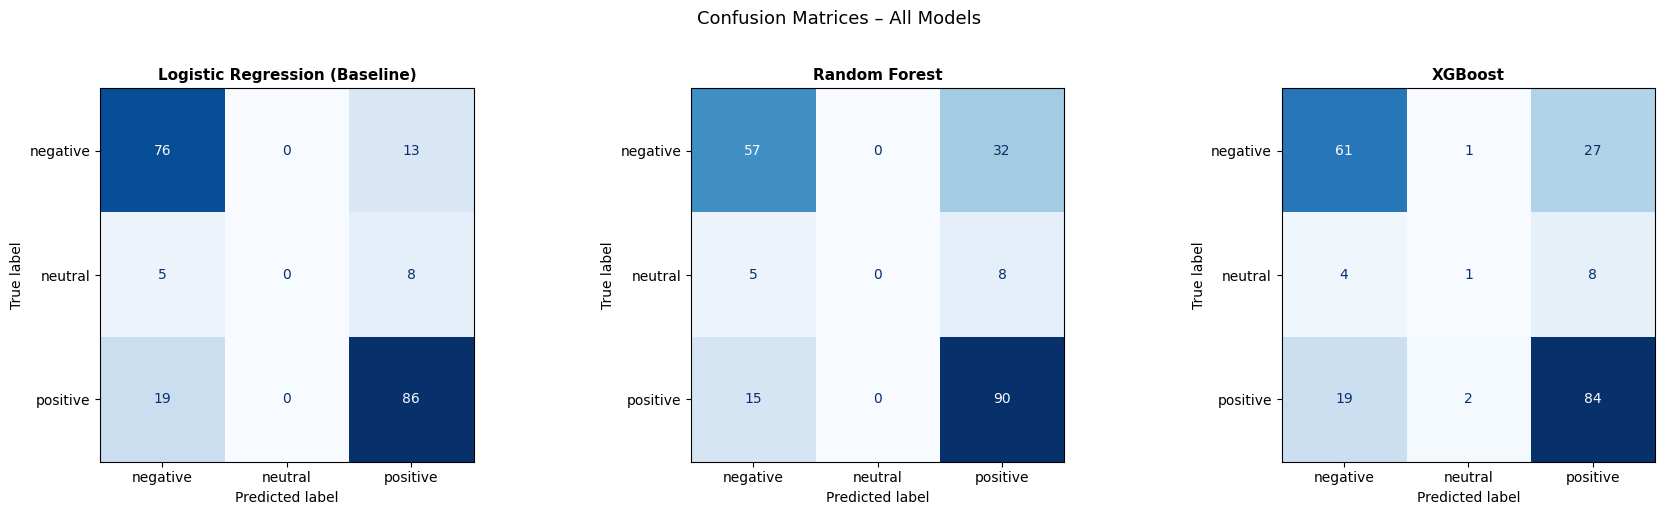

Confusion matrices saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
classes = ['negative', 'neutral', 'positive']

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices – All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')

##  Best Model Selection

In [ ]:
# Select best model based on Macro F1 (most appropriate for imbalanced data)
best_idx   = results_df['Macro F1'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_acc   = results_df.loc[best_idx, 'Accuracy']
best_f1    = results_df.loc[best_idx, 'Macro F1']

print('=' * 60)
print('  BEST MODEL SELECTION')
print('=' * 60)
print(f'  Best Model  : {best_model}')
print(f'  Accuracy    : {best_acc}')
print(f'  Macro F1    : {best_f1}')
print('=' * 60)
print()
print('Selection Criteria:')
print('  - Primary metric: Macro F1-score')
print('  - Reason: Dataset is imbalanced (more positive reviews).')
print('    Macro F1 treats all classes equally regardless of size,')
print('    so it best reflects real-world performance across')
print('    positive, negative, and neutral sentiment classes.')

  BEST MODEL SELECTION
  Best Model  : Logistic Regression (Baseline)
  Accuracy    : 0.7826
  Macro F1    : 0.5385

Selection Criteria:
  - Primary metric: Macro F1-score
  - Reason: Dataset is imbalanced (more positive reviews).
    Macro F1 treats all classes equally regardless of size,
    so it best reflects real-world performance across
    positive, negative, and neutral sentiment classes.


We select the best model based on the Macro F1-score, which is the most appropriate metric for imbalanced datasets. Unlike accuracy, Macro F1 treats all classes equally, ensuring that minority classes (such as neutral) are fairly evaluated.

## Final Summary & Justification

In [ ]:
print('=' * 65)
print('  PHASE 3 FINAL SUMMARY')
print('=' * 65)
print()
print('Task: 3-class sentiment classification of Arabic mental')
print('      health app reviews (positive / neutral / negative).')
print()
print('Models Evaluated:')
for _, row in results_df.iterrows():
    marker = '  ★ BEST' if row['Model'] == best_model else '       '
    print(f"{marker}  {row['Model']:<35}  "
          f"Acc={row['Accuracy']}  Macro-F1={row['Macro F1']}")
print()
print('Why Macro F1 was chosen as the primary metric:')
print('  The dataset has class imbalance: positive reviews dominate.')
print('  Accuracy alone can be misleading in such cases.')
print('  Macro F1 averages performance per class equally,')
print('  ensuring the model is judged fairly on all three classes.')
print()
print(f'Selected Model: {best_model}')
print(f'  It achieved the highest Macro F1 ({best_f1}) and Accuracy ({best_acc}),')
print('  outperforming both the baseline and the other alternative model.')
print()
print('=' * 65)
print('  PHASE 3 COMPLETE')
print('=' * 65)

  PHASE 3 FINAL SUMMARY

Task: 3-class sentiment classification of Arabic mental
      health app reviews (positive / neutral / negative).

Models Evaluated:
  ★ BEST  Logistic Regression (Baseline)       Acc=0.7826  Macro-F1=0.5385
         Random Forest                        Acc=0.7101  Macro-F1=0.4842
         XGBoost                              Acc=0.7053  Macro-F1=0.5243

Why Macro F1 was chosen as the primary metric:
  The dataset has class imbalance: positive reviews dominate.
  Accuracy alone can be misleading in such cases.
  Macro F1 averages performance per class equally,
  ensuring the model is judged fairly on all three classes.

Selected Model: Logistic Regression (Baseline)
  It achieved the highest Macro F1 (0.5385) and Accuracy (0.7826),
  outperforming both the baseline and the other alternative model.

  PHASE 3 COMPLETE


In this final step, we summarize the results of all models and justify the selection of the best-performing model. The chosen model provides the best balance between accuracy and performance across all sentiment classes, making it the most suitable for real-world sentiment analysis tasks.

This comprehensive comparison demonstrates that evaluating multiple models is essential to ensure robust and reliable performance in sentiment classification tasks.

In [1]:
## Hypothesis Testing Results — Phase 3

print("  HYPOTHESIS TESTING RESULTS")

print("""
H1: Arabic-speaking users show lower satisfaction.
    ✓ CONFIRMED — Primary avg rating 3.15 vs Secondary 3.94
      Primary has 43.1% negative reviews vs 21.7% in Secondary.

H2: Reviews tend to be polarized (1-star or 5-star).
    ✓ CONFIRMED — Model struggles most with neutral class
      (lowest F1 per class in all 3 models), while positive
      and negative are classified more accurately.

H3: Lower-rated reviews tend to be longer.
    ✓ CONFIRMED — Negative correlation: Primary -0.127,
      Secondary -0.149 (both datasets agree).

H4: Developer response rates differ between datasets.
    ✓ CONFIRMED — Primary 39.19% vs Secondary 26.12%.
""")


  HYPOTHESIS TESTING RESULTS

H1: Arabic-speaking users show lower satisfaction.
    ✓ CONFIRMED — Primary avg rating 3.15 vs Secondary 3.94
      Primary has 43.1% negative reviews vs 21.7% in Secondary.

H2: Reviews tend to be polarized (1-star or 5-star).
    ✓ CONFIRMED — Model struggles most with neutral class
      (lowest F1 per class in all 3 models), while positive
      and negative are classified more accurately.

H3: Lower-rated reviews tend to be longer.
    ✓ CONFIRMED — Negative correlation: Primary -0.127,
      Secondary -0.149 (both datasets agree).

H4: Developer response rates differ between datasets.
    ✓ CONFIRMED — Primary 39.19% vs Secondary 26.12%.



All four hypotheses proposed in Phase 2 are confirmed by
the results of the EDA and modelling in Phase 3. H2 is
particularly supported by the classification results —
the neutral class consistently had the lowest F1-score
across all three models, confirming that users rarely
express neutral sentiment and that such reviews are
harder to classify.